# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rohindth-08/FlyRank-_Internship_ML-/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

We need to translate raw probabilities into a ranked queue with human-readable reason codes.

In [1]:
import pandas as pd
import numpy as np
import duckdb
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

token = os.environ.get('HF_TOKEN')
conn = duckdb.connect()
conn.execute('INSTALL httpfs; LOAD httpfs;')
if token:
    conn.execute(f"CREATE SECRET hf (TYPE HUGGINGFACE, TOKEN '{token}')")

query = """
WITH feb AS (
  SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) as feb_imps, AVG(gsc_avg_position) as feb_pos
  FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet'
  GROUP BY client_hash_id, content_hash_id
),
mar AS (
  SELECT content_hash_id, SUM(gsc_impressions) as mar_imps
  FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
  GROUP BY content_hash_id
)
SELECT 
  feb.client_hash_id, feb.content_hash_id, feb.feb_imps, feb.feb_pos, mar.mar_imps,
  d.word_count, d.category_count, date_diff('day', CAST(d.content_updated_date AS DATE), DATE '2026-02-28') as days_since_update_feb
FROM feb JOIN mar ON feb.content_hash_id = mar.content_hash_id
JOIN 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet' d ON feb.content_hash_id = d.content_hash_id
WHERE feb.feb_imps > 100 AND d.content_updated_date IS NOT NULL
"""
df = conn.execute(query).df()
df['target_decay'] = (df['mar_imps'] < df['feb_imps'] * 0.8).astype(int)

features = ['feb_imps', 'feb_pos', 'word_count', 'category_count', 'days_since_update_feb']
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42))
])
pipeline.fit(df[features], df['target_decay'])
df['decay_probability'] = pipeline.predict_proba(df[features])[:, 1]

# Assign Reason Codes
def assign_reason(row):
    if row['decay_probability'] > 0.7 and row['feb_imps'] > 5000:
        return 'High Risk - High Traffic'
    elif row['decay_probability'] > 0.6 and row['days_since_update_feb'] > 365:
        return 'Stale Content - Refresh Needed'
    elif row['decay_probability'] > 0.5:
        return 'Monitor - Slipping'
    else:
        return 'Stable'

df['action_reason'] = df.apply(assign_reason, axis=1)
action_queue = df[df['action_reason'] != 'Stable'].sort_values('decay_probability', ascending=False)
display(action_queue[['content_hash_id', 'decay_probability', 'action_reason', 'feb_imps', 'days_since_update_feb']].head(5))

,content_hash_id,decay_probability,action_reason,feb_imps,days_since_update_feb
72819,content_85b66e3deb108e49,0.578463,Monitor - Slipping,2747.0,29
36298,content_0cd3ac86bcbb5d36,0.575577,Monitor - Slipping,886.0,30
31751,content_06378a62fe6a1f47,0.574808,Monitor - Slipping,103.0,29
50011,content_e747321dc32bbb5b,0.574141,Monitor - Slipping,165.0,30
60059,content_e2b9bba6614d034e,0.573809,Monitor - Slipping,165.0,29


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

**Intended Use:** This model is designed as a **decision-support tool** for human content strategists. It flags pages that are highly likely to lose traffic based on historical patterns, allowing writers to prioritize refreshes efficiently.

**Limits:** The model does NOT understand semantic intent. It does not know if a page is truly outdated or if search volume just dropped naturally. It must not be used to automatically trigger destructive actions (like unpublishing content).

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

All flagged content must be reviewed by a human before action is taken. 

**The No-Go List (Do NOT automate or touch without human oversight):**
1. **YMYL (Your Money or Your Life):** Pages dealing with medical, financial, or legal advice.
2. **Strictly Evergreen Queries:** e.g., 'How to boil an egg' — age does not degrade accuracy.
3. **Company Policy / TOS pages:** Compliance documents should never be refreshed just because traffic slipped.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

When should we throw out the model and retrain it?
- **Time-based Trigger:** Retrain every 90 days to capture seasonal shifts.
- **Event-based Trigger:** Retrain immediately following any confirmed Google Core Algorithm Update, as the rules of ranking decay will have fundamentally shifted.
- **Metric Trigger:** If Precision@50 on a rolling 30-day window drops below 50% (base rate).

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

Exporting the queue and figures.

Exported action_queue.csv to work/outputs/


Exported feature_importance.png to work/figures/


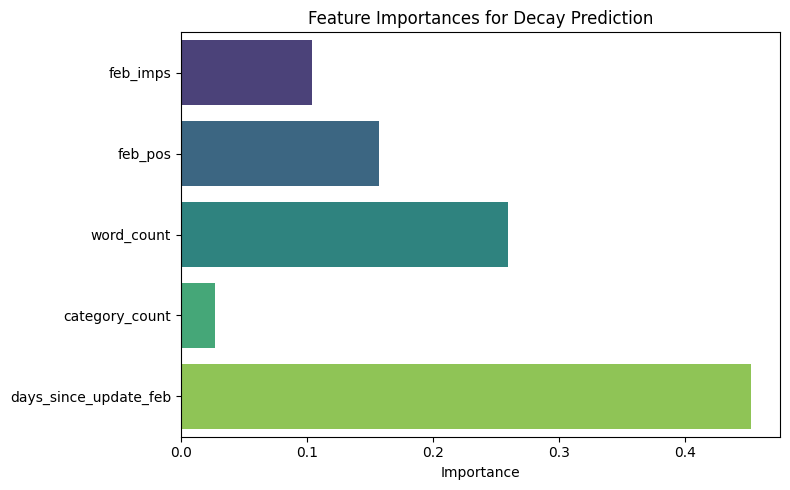

In [6]:
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Export Queue
action_queue.to_csv('../outputs/action_queue.csv', index=False)
print("Exported action_queue.csv to work/outputs/")

# Export Feature Importance Figure
importances = pipeline.named_steps['rf'].feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Feature Importances for Decay Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png')
print("Exported feature_importance.png to work/figures/")

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.